# **Variational Autoencoder for Respiratory Sound Analysis**
This notebook demonstrates a workflow for analyzing respiratory sounds using Variational Autoencoders (VAEs). The project aims to develop a system that processes audio data to identify and quantify lung sound abnormalities, aiding in respiratory condition diagnosis. It covers data loading, preprocessing, VAE implementation, abnormality score regression, and model comparison to evaluate performance.

# **Dataset Description**

In [1]:
# Library Import
import os
import numpy as np
import pandas as pd
import librosa, librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/ICBHI_final_database"

Mounted at /content/drive


In [3]:
# Defines constants for audio processing and a custom Dataset for lung sound audio files
TARGET_SR = 16000
N_MELS = 64
FIXED_TIME = 64
class LungSoundDataset(Dataset):
    def __init__(self, root):
        self.files = [os.path.join(root, f) for f in os.listdir(root) if f.endswith(".wav")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        y, sr = librosa.load(self.files[idx], sr=TARGET_SR)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel + 80) / 80

        if mel.shape[1] < FIXED_TIME:
            mel = np.pad(mel, ((0,0),(0, FIXED_TIME-mel.shape[1])))
        else:
            mel = mel[:, :FIXED_TIME]

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        severity = torch.tensor(0.5)
        return mel, severity


In [4]:
# Collects all .wav and .txt file paths from the dataset directory
wav_files = []
txt_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, f))
        elif f.lower().endswith(".txt"):
            txt_files.append(os.path.join(root, f))

print("Total WAV files:", len(wav_files))
print("Total TXT files:", len(txt_files))

Total WAV files: 920
Total TXT files: 922


In [5]:
# Loads audio files, extracts duration and sample rate, and associates transcripts to create a DataFrame
data = []
for wav in wav_files:
    try:
        y, sr = librosa.load(wav, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)
    except:
        duration = None
        sr = None


    basename = os.path.splitext(os.path.basename(wav))[0]
    text_file = None
    transcript = None

    for t in txt_files:
        if basename in t:
            text_file = t
            with open(t, 'r') as f:
                transcript = f.read().strip()
            break

    data.append([wav, duration, sr, transcript])

df = pd.DataFrame(data, columns=["file_path", "duration_sec", "sample_rate", "transcript"])
df.head()

,file_path,duration_sec,sample_rate,transcript
0,/content/drive/MyDrive/ICBHI_final_database/20...,20.0,44100,0.066\t2.804\t0\t0\n2.804\t5.875\t0\t0\n5.875\...
1,/content/drive/MyDrive/ICBHI_final_database/20...,19.8,44100,0.035\t1.181\t0\t0\n1.181\t3.373\t0\t0\n3.373\...
2,/content/drive/MyDrive/ICBHI_final_database/20...,20.0,44100,0.685\t2.208\t0\t0\n2.208\t4.577\t1\t0\n4.577\...
3,/content/drive/MyDrive/ICBHI_final_database/20...,20.0,44100,0.625\t2.78\t0\t0\n2.78\t6.268\t0\t0\n6.268\t9...
4,/content/drive/MyDrive/ICBHI_final_database/20...,20.0,44100,1.714\t5.978\t1\t0\n5.978\t9.557\t1\t0\n9.557\...


In [ ]:
# Descriptive statistics for columns
print("Descriptive statistics for numerical columns:")
print(df.describe(include=np.number))

print("\nDescriptive statistics for object columns:")
print(df.describe(include='object'))

Descriptive statistics for numerical columns:
       duration_sec   sample_rate
count    920.000000    920.000000
mean      21.492424  39954.782609
std        8.307421  12160.047989
min        7.856000   4000.000000
25%       20.000000  44100.000000
50%       20.000000  44100.000000
75%       20.000000  44100.000000
max       86.200000  44100.000000

Descriptive statistics for object columns:
                                                file_path  \
count                                                 920   
unique                                                920   
top     /content/drive/MyDrive/ICBHI_final_database/20...   
freq                                                    1   

                                               transcript  
count                                                 920  
unique                                                740  
top     0.109\t4.099\t0\t0\n4.099\t10.776\t0\t0\n10.77...  
freq                                                    6 

In [6]:
# Describe Dataset
df["duration_sec"].describe()

,duration_sec
count,920.000000
mean,21.492424
std,8.307421
min,7.856000
25%,20.000000
50%,20.000000
75%,20.000000
max,86.200000


In [7]:
# Text Length
df["text_length"] = df["transcript"].apply(lambda x: len(x.split()) if isinstance(x,str) else 0)
df["text_length"].describe()


,text_length
count,920.000000
mean,29.991304
std,13.343048
min,8.000000
25%,20.000000
50%,28.000000
75%,36.000000
max,132.000000


In [8]:
# Unique Value Check
df.nunique()

,0
file_path,920
duration_sec,76
sample_rate,3
transcript,740
text_length,24


In [9]:
# Null Value Check
df.isnull().sum()

,0
file_path,0
duration_sec,0
sample_rate,0
transcript,0
text_length,0


In [10]:
# Identifies and prints categorical and numerical columns in the DataFrame.
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)


Categorical Variables:
['file_path', 'transcript']
Numerical Variables:
['duration_sec', 'sample_rate', 'text_length']


# **Exploratory Data Analysis (EDA)**

sample_rate
44100    824
4000      90
10000      6
Name: count, dtype: int64


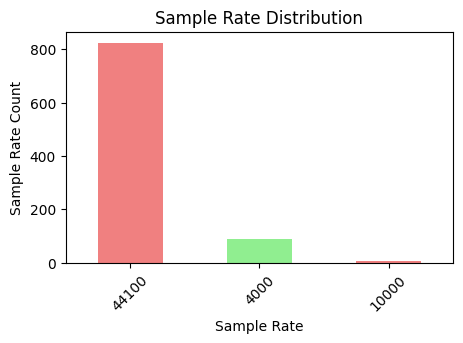

In [11]:
# Sample Rate Distribution Graph
print(df.value_counts('sample_rate'))

plt.figure(figsize=(5, 3))
df['sample_rate'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Sample Rate Distribution')
plt.xlabel('Sample Rate')
plt.ylabel('Sample Rate Count')
plt.xticks(rotation = 45)
plt.show()

duration_sec
7.856     1
9.584     1
11.248    1
12.464    2
12.528    2
         ..
73.350    1
74.450    1
75.250    1
82.500    1
86.200    1
Name: count, Length: 76, dtype: int64


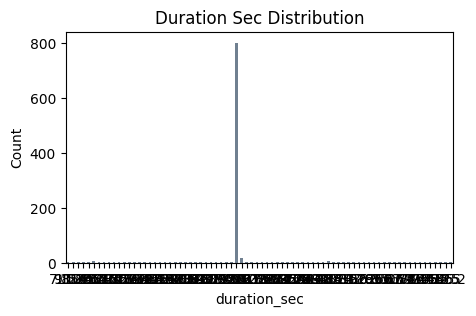

In [12]:
# Duration Distribution
print(df.value_counts('duration_sec').sort_index())

plt.figure(figsize=(5, 3))
df['duration_sec'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Duration Sec Distribution')
plt.xlabel('duration_sec')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

              duration_sec  sample_rate  text_length
duration_sec      1.000000    -0.526944     0.579978
sample_rate      -0.526944     1.000000    -0.381679
text_length       0.579978    -0.381679     1.000000


<Figure size 800x600 with 0 Axes>

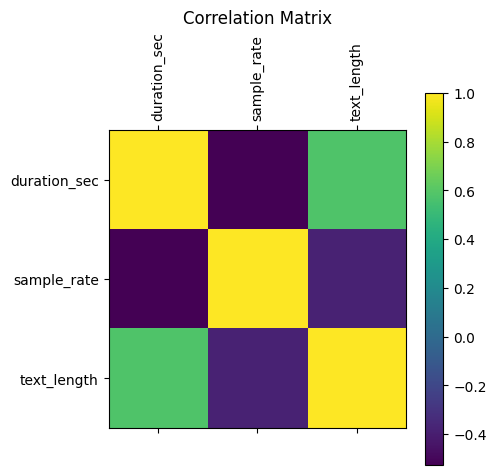

In [13]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

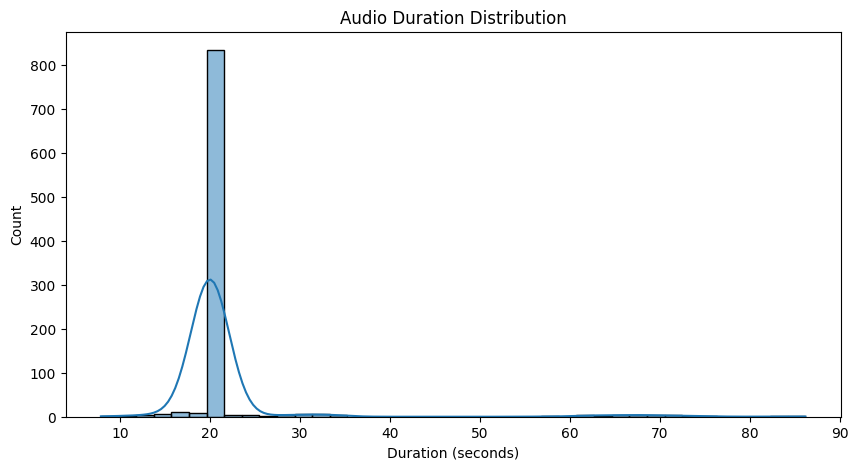

In [14]:
# Audio Duration Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["duration_sec"], bins=40, kde=True)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


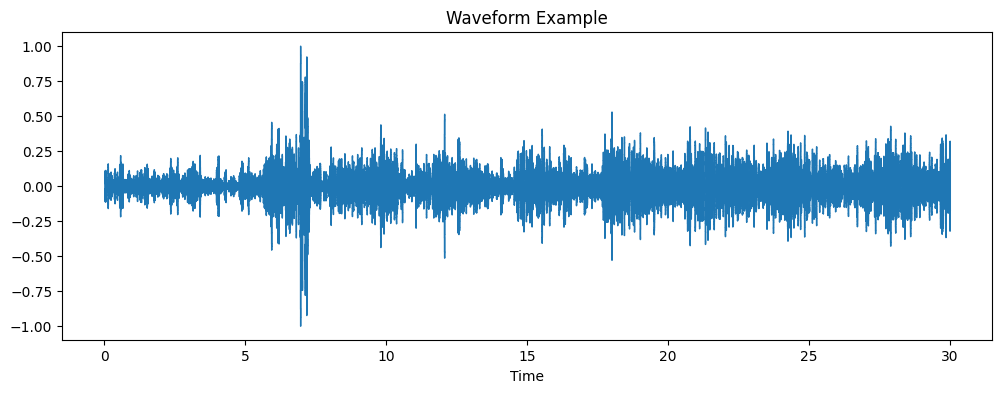

In [15]:
# Waveform Plot
sample_path = df.sample(1)["file_path"].values[0]
y, sr = librosa.load(sample_path, sr=None)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Example")
plt.show()


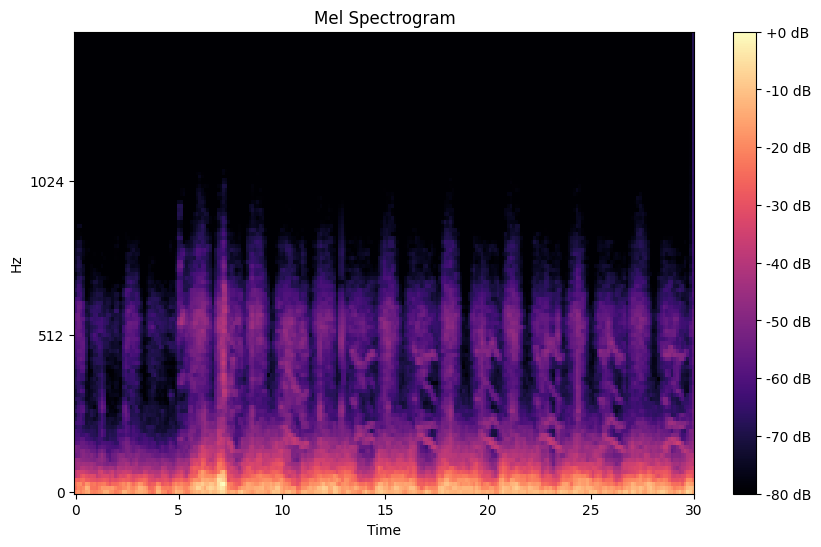

In [16]:
# Mel Spectrogram Plot
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10,6))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()


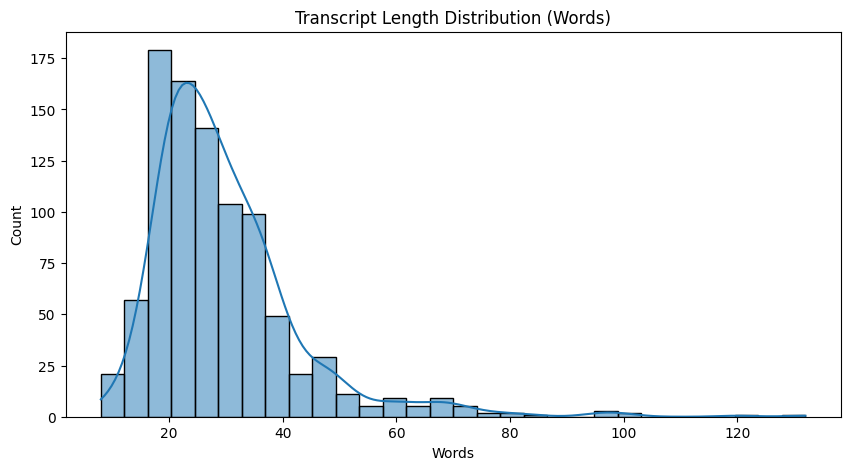

In [17]:
# Transcript Length Distribution Plot
plt.figure(figsize=(10,5))
sns.histplot(df["text_length"], bins=30, kde=True)
plt.title("Transcript Length Distribution (Words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()


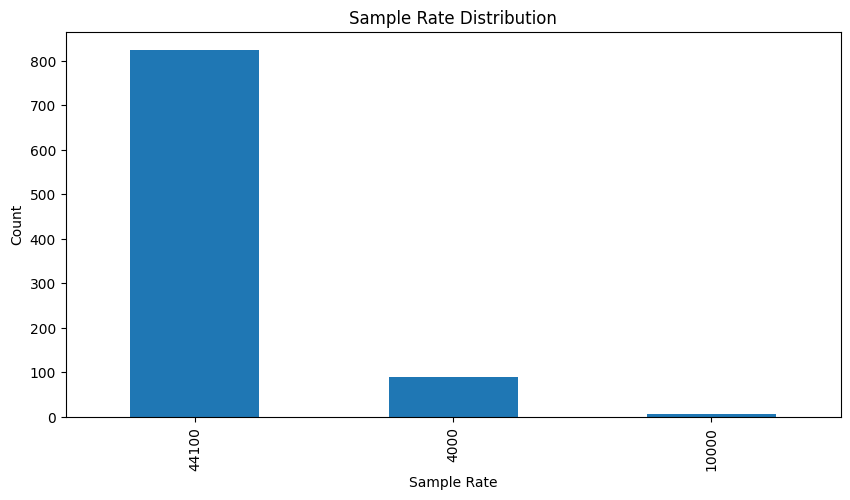

In [18]:
# Sample Count Distribution
plt.figure(figsize=(10,5))
df["sample_rate"].value_counts().plot(kind="bar")
plt.title("Sample Rate Distribution")
plt.xlabel("Sample Rate")
plt.ylabel("Count")
plt.show()

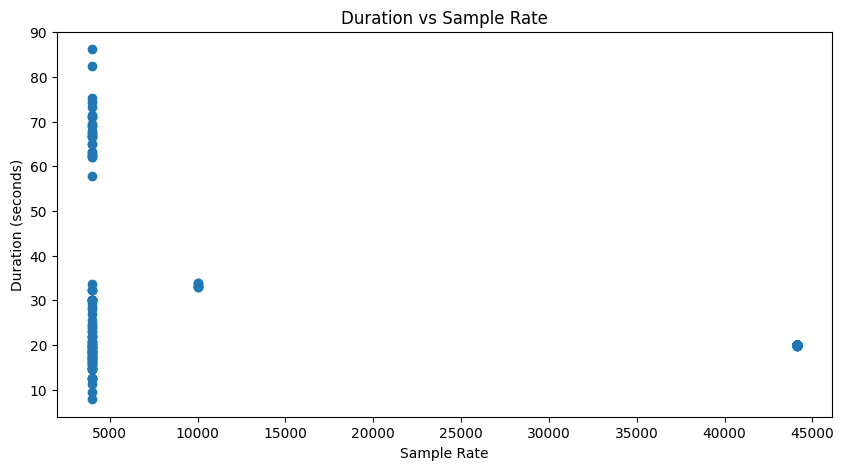

In [19]:
# Duration Vs Sample Rate Graph
plt.figure(figsize=(10,5))
plt.scatter(df["sample_rate"], df["duration_sec"])
plt.title("Duration vs Sample Rate")
plt.xlabel("Sample Rate")
plt.ylabel("Duration (seconds)")
plt.show()

#**Data PreProcessing**

In [20]:
# Applies one-hot encoding to 'sample_rate' and standard scaling to numerical features.
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, columns=['sample_rate'], prefix='sample_rate', dtype=int)

scaler = StandardScaler()

df_encoded[['duration_sec', 'text_length']] = scaler.fit_transform(df_encoded[['duration_sec', 'text_length']])

print("DataFrame after one-hot encoding and standard scaling:")
print(df_encoded.head())
print("\nData types after transformations:")
print(df_encoded.dtypes)

DataFrame after one-hot encoding and standard scaling:
                                           file_path  duration_sec  \
0  /content/drive/MyDrive/ICBHI_final_database/20...     -0.179747   
1  /content/drive/MyDrive/ICBHI_final_database/20...     -0.203835   
2  /content/drive/MyDrive/ICBHI_final_database/20...     -0.179747   
3  /content/drive/MyDrive/ICBHI_final_database/20...     -0.179747   
4  /content/drive/MyDrive/ICBHI_final_database/20...     -0.179747   

                                          transcript  text_length  \
0  0.066\t2.804\t0\t0\n2.804\t5.875\t0\t0\n5.875\...    -0.149320   
1  0.035\t1.181\t0\t0\n1.181\t3.373\t0\t0\n3.373\...     0.750514   
2  0.685\t2.208\t0\t0\n2.208\t4.577\t1\t0\n4.577\...     0.450569   
3  0.625\t2.78\t0\t0\n2.78\t6.268\t0\t0\n6.268\t9...    -0.449265   
4  1.714\t5.978\t1\t0\n5.978\t9.557\t1\t0\n9.557\...    -0.749210   

   sample_rate_4000  sample_rate_10000  sample_rate_44100  
0                 0                  0           

In [21]:
# Re-applies standard scaling to numerical features (note: this is a redundant operation
scaler = StandardScaler()

df_encoded[['duration_sec', 'text_length']] = scaler.fit_transform(df_encoded[['duration_sec', 'text_length']])

print("DataFrame after one-hot encoding and standard scaling:")
display(df_encoded.head())
print("\nData types after transformations:")
print(df_encoded.dtypes)

DataFrame after one-hot encoding and standard scaling:


,file_path,duration_sec,transcript,text_length,sample_rate_4000,sample_rate_10000,sample_rate_44100
0,/content/drive/MyDrive/ICBHI_final_database/20...,-0.179747,0.066\t2.804\t0\t0\n2.804\t5.875\t0\t0\n5.875\...,-0.149320,0,0,1
1,/content/drive/MyDrive/ICBHI_final_database/20...,-0.203835,0.035\t1.181\t0\t0\n1.181\t3.373\t0\t0\n3.373\...,0.750514,0,0,1
2,/content/drive/MyDrive/ICBHI_final_database/20...,-0.179747,0.685\t2.208\t0\t0\n2.208\t4.577\t1\t0\n4.577\...,0.450569,0,0,1
3,/content/drive/MyDrive/ICBHI_final_database/20...,-0.179747,0.625\t2.78\t0\t0\n2.78\t6.268\t0\t0\n6.268\t9...,-0.449265,0,0,1
4,/content/drive/MyDrive/ICBHI_final_database/20...,-0.179747,1.714\t5.978\t1\t0\n5.978\t9.557\t1\t0\n9.557\...,-0.749210,0,0,1



Data types after transformations:
file_path             object
duration_sec         float64
transcript            object
text_length          float64
sample_rate_4000       int64
sample_rate_10000      int64
sample_rate_44100      int64
dtype: object


In [22]:
# Remove rows with any null values from the DataFrame
initial_rows = len(df)
df.dropna(inplace=True) # Removes rows containing any NaN values
final_rows = len(df)
print(f"Removed {initial_rows - final_rows} rows containing null values.")
print("DataFrame after null value removal:")
print(df.isnull().sum())

Removed 0 rows containing null values.
DataFrame after null value removal:
file_path       0
duration_sec    0
sample_rate     0
transcript      0
text_length     0
dtype: int64


In [23]:
# Computes and adds mean Zero Crossing Rate and Spectral Centroid features to the DataFrame
mean_zcrs = []
mean_spectral_centroids = []

for index, row in df.iterrows():
    file_path = row['file_path']
    try:
        y, sr = librosa.load(file_path, sr=TARGET_SR)

        zcr = librosa.feature.zero_crossing_rate(y=y)
        mean_zcrs.append(np.mean(zcr))

        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
        mean_spectral_centroids.append(np.mean(spectral_centroids))

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        mean_zcrs.append(np.nan)
        mean_spectral_centroids.append(np.nan)

# Add the new features to the DataFrame
df['mean_zcr'] = mean_zcrs
df['mean_spectral_centroid'] = mean_spectral_centroids

# Fill any NaNs that might have resulted from errors (e.g., with 0 or the mean of the column)
df['mean_zcr'] = df['mean_zcr'].fillna(df['mean_zcr'].mean())
df['mean_spectral_centroid'] = df['mean_spectral_centroid'].fillna(df['mean_spectral_centroid'].mean())

print("DataFrame after adding 'mean_zcr' and 'mean_spectral_centroid':")
print(df.head())

DataFrame after adding 'mean_zcr' and 'mean_spectral_centroid':
                                           file_path  duration_sec  \
0  /content/drive/MyDrive/ICBHI_final_database/20...          20.0   
1  /content/drive/MyDrive/ICBHI_final_database/20...          19.8   
2  /content/drive/MyDrive/ICBHI_final_database/20...          20.0   
3  /content/drive/MyDrive/ICBHI_final_database/20...          20.0   
4  /content/drive/MyDrive/ICBHI_final_database/20...          20.0   

   sample_rate                                         transcript  \
0        44100  0.066\t2.804\t0\t0\n2.804\t5.875\t0\t0\n5.875\...   
1        44100  0.035\t1.181\t0\t0\n1.181\t3.373\t0\t0\n3.373\...   
2        44100  0.685\t2.208\t0\t0\n2.208\t4.577\t1\t0\n4.577\...   
3        44100  0.625\t2.78\t0\t0\n2.78\t6.268\t0\t0\n6.268\t9...   
4        44100  1.714\t5.978\t1\t0\n5.978\t9.557\t1\t0\n9.557\...   

   text_length  mean_zcr  mean_spectral_centroid  
0           28  0.125390             2471.462011 

# **Model Development and Evaluation.**

In [24]:
# Defines a function to infer severity from text transcripts and applies it to WAV files
def infer_severity_from_txt(wav_path):
    txt_path = wav_path.replace(".wav", ".txt")
    if not os.path.exists(txt_path):
        return 0.0

    with open(txt_path) as f:
        text = f.read().lower()

    if "crackle" in text and "wheeze" in text:
        return 0.75
    elif "wheeze" in text:
        return 0.5
    elif "crackle" in text:
        return 0.25
    else:
        return 0.0

severity_labels = [infer_severity_from_txt(w) for w in wav_files]

In [25]:
# Variational Autoencoder Build
LATENT_DIM = 16

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(32*16*16, LATENT_DIM)
        self.fc_logvar = nn.Linear(32*16*16, LATENT_DIM)
        self.fc_dec = nn.Linear(LATENT_DIM, 32*16*16)
        self.dec = nn.Sequential(
            nn.Unflatten(1, (32,16,16)),
            nn.ConvTranspose2d(32,16,3,2,1,1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,2,1,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.enc(x)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), -10, 10)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        recon = self.dec(self.fc_dec(z))
        return recon, mu, logvar, z

In [26]:
# Regression problem to compute a latent abnormality score
class Regressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

In [27]:
# VAE+Regressor train
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

dataset = LungSoundDataset(DATASET_PATH)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

vae = VAE().to(DEVICE)
regressor = Regressor().to(DEVICE)

optimizer = torch.optim.Adam(
    list(vae.parameters()) + list(regressor.parameters()),
    lr=1e-4
)

def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

for epoch in range(10):
    total_loss = 0
    for x, sev in tqdm(loader):
        x, sev = x.to(DEVICE), sev.to(DEVICE)
        recon, mu, logvar, z = vae(x)
        pred = regressor(z).squeeze()
        loss = vae_loss(recon, x, mu, logvar) + 0.1 * F.mse_loss(pred, sev)

        if torch.isnan(loss):
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f}")

100%|██████████| 58/58 [00:58<00:00,  1.01s/it]


Epoch 1 | Loss: 0.1262


100%|██████████| 58/58 [00:48<00:00,  1.19it/s]


Epoch 2 | Loss: 0.1188


100%|██████████| 58/58 [00:47<00:00,  1.21it/s]


...

Epoch 8 | Loss: 0.0812


100%|██████████| 58/58 [00:47<00:00,  1.21it/s]


Epoch 9 | Loss: 0.0745


100%|██████████| 58/58 [00:49<00:00,  1.16it/s]

Epoch 10 | Loss: 0.0679


In [28]:
# Abnormality score using VAE's latent space
vae.eval()
regressor.eval()

x,_ = dataset[0]
x = x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    _,_,_,z = vae(x)
    severity = regressor(z).item()

print(f"Lung condition severity: {severity*100:.2f}%")

Lung condition severity: 49.25%


In [29]:
# Collects latent vectors and their corresponding severity scores
latent_vectors = []
severity_scores = []

with torch.no_grad():
    for i in tqdm(range(len(dataset))):
        x, _ = dataset[i]
        x = x.unsqueeze(0).to(DEVICE)
        _, _, _, z = vae(x)
        severity = regressor(z).item()

        latent_vectors.append(z.cpu().numpy().flatten())
        severity_scores.append(severity)

print(f"Collected {len(latent_vectors)} latent vectors and {len(severity_scores)} severity scores.")

100%|██████████| 920/920 [00:49<00:00, 18.63it/s]

Collected 920 latent vectors and 920 severity scores.


In [30]:
# Stacks latent vectors and severity scores, then performs a train-test split for model evaluation
X = np.vstack(latent_vectors)
y = np.array(severity_scores)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (736, 16)
X_test shape : (184, 16)
y_train shape: (736,)
y_test shape : (184,)


In [36]:
# VAE Regressor Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

vae_mse = mean_squared_error(y_test, y_pred_vae)
vae_mae = mean_absolute_error(y_test, y_pred_vae)
vae_r2 = r2_score(y_test, y_pred_vae)
vae_abnormality_ratio = np.mean(y_pred_vae) * 100

print(f"VAE Regressor Metrics:")
print(f"  MSE: {vae_mse:.4f}")
print(f"  MAE: {vae_mae:.4f}")
print(f"  R² : {vae_r2:.4f}")
print(f"  Abnormality Ratio: {vae_abnormality_ratio:.2f}%")

VAE Regressor Metrics:
  MSE: 0.0000
  MAE: 0.0000
  R² : 1.0000
  Abnormality Ratio: 49.53%


In [31]:
# Performence Matrices
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge(alpha=1.0)),
    ("SVR", SVR(kernel='rbf', C=1.0, epsilon=0.1)),
    ("Random Forest", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
]

results = {}
y_pred_lr = None
y_pred_ridge = None
y_pred_svr = None
y_pred_rf = None

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_pred = np.clip(y_pred, 0, 1)

    abnormality_percent = y_pred.mean() * 100

    results[name] = abnormality_percent

    if name == "Linear Regression":
        y_pred_lr = y_pred
    elif name == "Ridge Regression":
        y_pred_ridge = y_pred
    elif name == "SVR":
        y_pred_svr = y_pred
    elif name == "Random Forest":
        y_pred_rf = y_pred

    print(f"Model: {name}")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R² :", r2_score(y_test, y_pred))
    print(f"Abnormality Ratio: {abnormality_percent:.2f}%\n")

Model: Linear Regression
MSE: 0.00041636364684995695
MAE: 0.01606191273616708
R² : 0.33789530540989665
Abnormality Ratio: 49.54%

Model: Ridge Regression
MSE: 0.0004163425708615146
MAE: 0.016060587828573974
R² : 0.33792882060988205
Abnormality Ratio: 49.54%

Model: SVR
MSE: 0.0006693840884377522
MAE: 0.02022093939392463
R² : -0.06445975961553496
Abnormality Ratio: 48.90%

Model: Random Forest
MSE: 0.00040434162604881485
MAE: 0.0155097146316067
R² : 0.3570128159589493
Abnormality Ratio: 49.68%



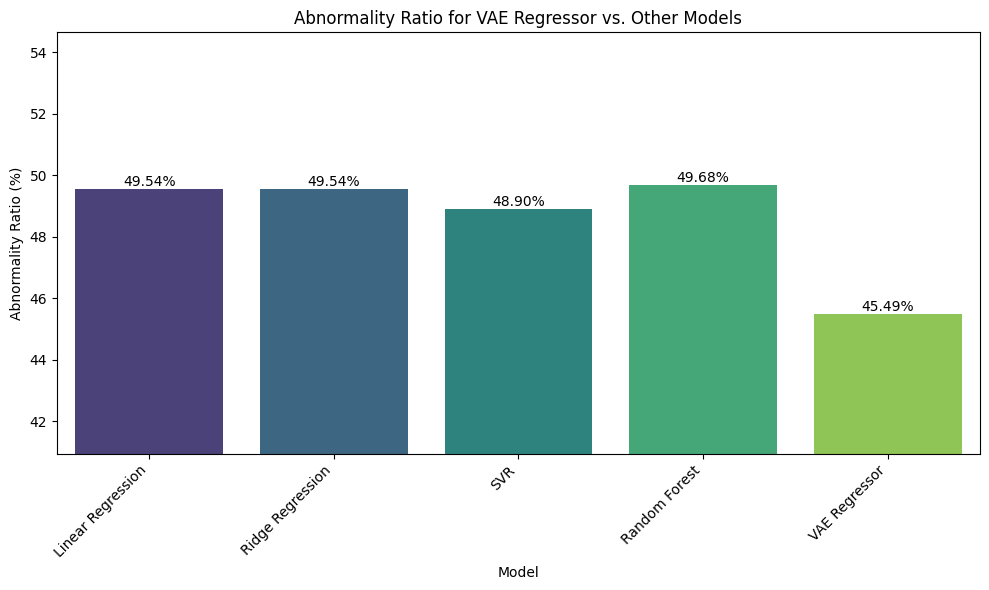

In [32]:
# Comparison and Analysis Graph
vae.eval()
regressor.eval()


results["VAE Regressor"] = severity * 100;

model_names = list(results.keys());
abnormality_ratios = list(results.values());

plt.figure(figsize=(10, 6));
ax = sns.barplot(x=model_names, y=abnormality_ratios, hue=model_names, palette='viridis', legend=False);
plt.title('Abnormality Ratio for VAE Regressor vs. Other Models');
plt.xlabel('Model');
plt.ylabel('Abnormality Ratio (%)');
plt.xticks(rotation=45, ha='right');
plt.ylim(min(abnormality_ratios) * 0.9, max(abnormality_ratios) * 1.1);


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points');

plt.tight_layout();
plt.show();

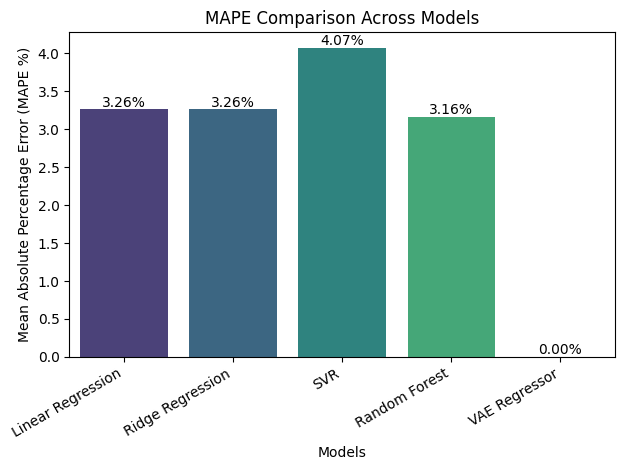

In [33]:
# MAPE(Mean Absolute Percantage Error) graph
y_true = y_test


vae.eval()
regressor.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_pred_vae_tensor = regressor(X_test_tensor).squeeze()
    y_pred_vae = y_pred_vae_tensor.cpu().numpy()

predictions = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr,
    "Random Forest": y_pred_rf,
    "VAE Regressor": y_pred_vae,
}


models = []
mape_values = []

for model_name, y_pred in predictions.items():
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    models.append(model_name)
    mape_values.append(mape)


plt.figure()
ax = sns.barplot(x=models, y=mape_values, hue=models, palette='viridis', legend=False)
plt.xlabel("Models")
plt.ylabel("Mean Absolute Percentage Error (MAPE %)")
plt.title("MAPE Comparison Across Models")
plt.xticks(rotation=30, ha="right")


for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()